## HOME LOAN EXPLORATORY DATA ANALYSIS

Project Overview
 In this project, you will conduct an in-depth Exploratory Data Analysis (EDA) on a Home Loan dataset. The objective is to 
 
 understand the underlying structure, trends, and relationships in the data through data cleaning, visualization, and 
 
 statistical analysis. This initial investigation is essential for uncovering patterns that may influence loan approvals and 
 
 risk assessment.


In [382]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Task 1: Data Ingestion

In [383]:
#ingesting train dataset for EDA

df1 = pd.read_csv("loan-train.csv")
df1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [384]:
df = df1.copy()

In [385]:
# Checking data shape before joining train and test dataset together
df.shape

(614, 13)

## Preliminary Data Analysis

In [386]:
# Checking the shape of the new joined dataset
df.shape

(614, 13)

In [387]:
# chcking the tail of the new dataset to see if the index number is aligned
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [388]:
# checking the column names of the dataset

df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [389]:
# checking information about each column in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# Task1.2: Data Inspection

In [390]:
# checking the number missing data per columns 

df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Checking for Duplicates

In [391]:
df_duplicate = df.duplicated().sum()
df_duplicate


# We have no duplicate column

np.int64(0)

Data Types Inconsistency

In [392]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

WIll change Apllicant income to float64 for better representation

## Task 1.3: Clean the dataset by handling missing values, correcting data types, and addressing outliers.

Handling columns with missing data

In [393]:
# 1- Handling Gender missing data
# knowing the most present gender
gender_mode= df["Gender"].mode()[0]
print("The highest borrowing gender is", gender_mode)

# fill missing data with mode 
df["Gender"] = df["Gender"].fillna(gender_mode)
print(f"\n {df["Gender"].head(5)}")
# check id there is still missing data 
print("\nThe number of missing data is", df["Gender"].isna().sum())

The highest borrowing gender is Male

 0    Male
1    Male
2    Male
3    Male
4    Male
Name: Gender, dtype: object

The number of missing data is 0


In [394]:
# 2- Handling Married missing data 

married_mode = df["Married"].mode()[0]
df["Married"] = df["Married"].fillna(married_mode)

# check id there is still missing data 
print("\nThe number of missing data for married is", df["Married"].isna().sum())


The number of missing data for married is 0


In [395]:
# 3- Handling Dependency Dataset

Dependents_mode = df["Dependents"].mode()[0]
df["Dependents"] = df["Dependents"].fillna(Dependents_mode)

# check id there is still missing data 
print("\nThe number of missing data for Dependents is", df["Dependents"].isna().sum())


The number of missing data for Dependents is 0


In [396]:
# checking the number missing data per columns 

df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [397]:
# 4- Handling Self_Employed Dataset

Self_Employed_mode = df["Self_Employed"].mode()[0]
df["Self_Employed"] = df["Self_Employed"].fillna(Self_Employed_mode)

# check id there is still missing data 
print("\nThe number of missing data for Self_Employed is", df["Self_Employed"].isna().sum())


The number of missing data for Self_Employed is 0


In [398]:
# 5- Handling Self_Employed Dataset 
# since loan amount is an important feature of the dataset and cannot be filled will with mean because of the present of outliers. Let's drop the rows

df.drop(df[df["LoanAmount"].isna()].index, inplace=True)

df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [399]:
# 6- Handling Loan Amount Term

Loan_Amount_Term_mode = df["Loan_Amount_Term"].mode()[0]
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(Loan_Amount_Term_mode)

# check id there is still missing data 
print("\nThe number of missing data for Loan_Amount_Term is", df["Loan_Amount_Term"].isna().sum())


The number of missing data for Loan_Amount_Term is 0


In [400]:
# 7-  HAndling Credit_History
# fill column with 0

df["Credit_History"].fillna(0, inplace=True)
df["Credit_History"].isna().sum()



np.int64(0)

In [401]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [402]:
df["Dependents"].value_counts()

Dependents
0     347
1      98
2      98
3+     49
Name: count, dtype: int64

In [403]:
df.head(8)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y


In [404]:
df["Dependents"].unique()

array(['1', '0', '2', '3+'], dtype=object)

In [405]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [406]:


df["ApplicantIncome"].astype("float64")

1      4583.0
2      3000.0
3      2583.0
4      6000.0
5      5417.0
        ...  
609    2900.0
610    4106.0
611    8072.0
612    7583.0
613    4583.0
Name: ApplicantIncome, Length: 592, dtype: float64

In [407]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

# Exploratory Data Analysis

Task 2.1: Conduct descriptive statistics to summarize the key characteristics of the data.

In [408]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,592.0,5404.304054,6164.073003,150.0,2887.25,3806.0,5754.5,81000.0
CoapplicantIncome,592.0,1642.633311,2967.717486,0.0,0.00,1221.0,2312.0,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.00,128.0,168.0,700.0
Loan_Amount_Term,592.0,342.567568,64.719325,12.0,360.00,360.0,360.0,480.0
Credit_History,592.0,0.773649,0.418823,0.0,1.00,1.0,1.0,1.0


Observations on Numeric features


|Feature                |Distribution     | Outliers        |Spread
|--------------------|-----------------------|-------------------|----------------|
|Applicants Income| widely distributed| Heavily present| Widely spread|
|Coapplicant Incomme| roughly normal | heavily present especially from 25% -50% and 75%-max(100%) | widely spread
|Loan Amount | roughly normal | Heavily present |roughly spread |
|Loan Amount Term | roughly normal |Present between 75% - max(100%) |
|Credit History|normal | Absent apart from borrowers in the minimum range |moderately spread| 

In [409]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [410]:

df["Dependents"] = df["Dependents"].replace({0: "0", 1:"2", 2:"1", 4:"+3"})
df["Dependents"].value_counts()

Dependents
0     347
1      98
2      98
3+     49
Name: count, dtype: int64

In [411]:
# Let set loan ID as index 
df.set_index("Loan_ID", inplace=True)

In [412]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [413]:
df["Dependents"].value_counts()

Dependents
0     347
1      98
2      98
3+     49
Name: count, dtype: int64

# Univariate Analysis

Task 2.2: Visualize distributions of numerical features (e.g., applicant income, loan amount) using histograms and box plots.

In [414]:
df.head(1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [415]:
# lets pick out the numerical columns and get the descriptions
num_features = df.select_dtypes(include=['float64', 'int64']).columns
num_features

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [416]:
def num_vis_dist(df, feature):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f"Histogram Distribution of {feature}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[feature])
    plt.title(f"Boxplot visualization of {feature}")

    plt.tight_layout()
    plt.show()

In [417]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 592 entries, LP001003 to LP002990
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             592 non-null    object 
 1   Married            592 non-null    object 
 2   Dependents         592 non-null    object 
 3   Education          592 non-null    object 
 4   Self_Employed      592 non-null    object 
 5   ApplicantIncome    592 non-null    int64  
 6   CoapplicantIncome  592 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   592 non-null    float64
 9   Credit_History     592 non-null    float64
 10  Property_Area      592 non-null    object 
 11  Loan_Status        592 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 60.1+ KB


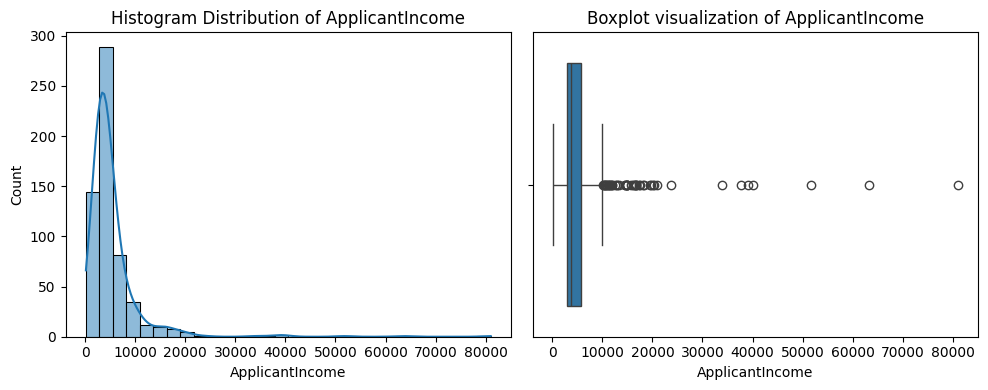

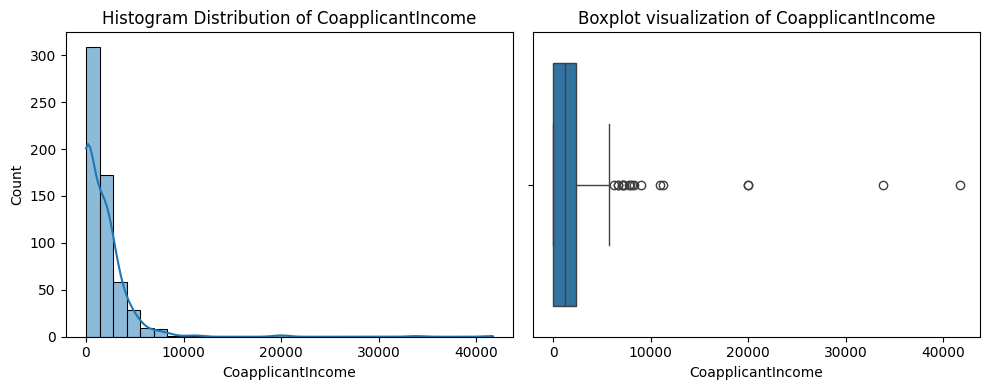

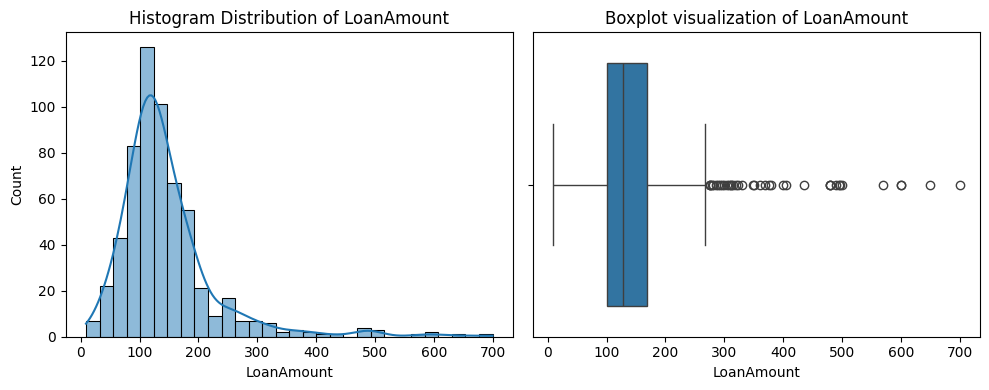

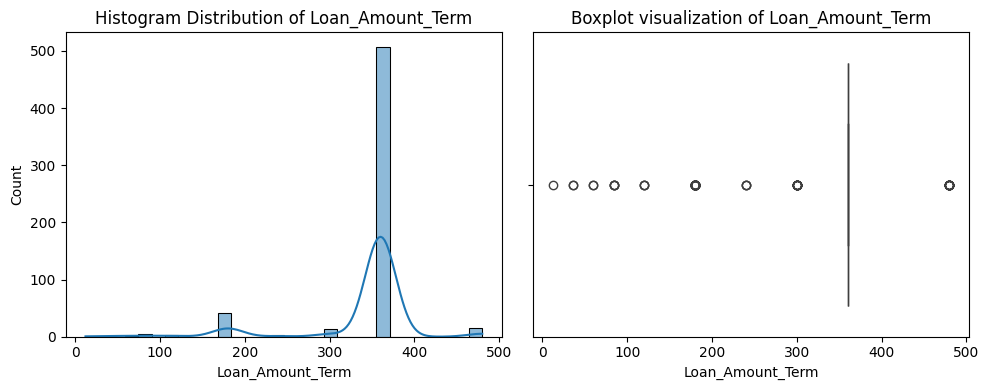

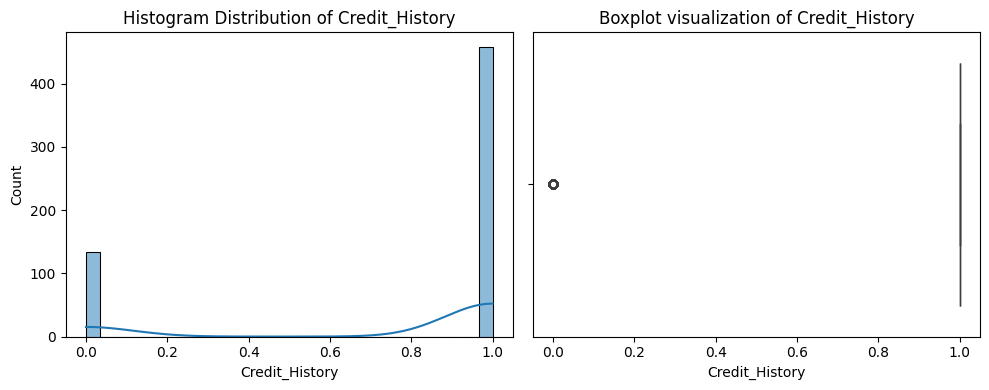

In [418]:
for feature in num_features:
    num_vis_dist(df, feature)

In [419]:
# df["Dependents"] = df["Dependents"].replace("3+", 4)
# df["Dependents"]= df["Dependents"].astype("int64")
# df["Dependents"].dtype

Task 2.3: Analyze categorical features (e.g., education, employment status, property area) using bar charts and pie charts.

In [420]:

categorical_features = df.select_dtypes(include=['object']).columns
categorical_features

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [421]:
for feature in categorical_features:
    print("+" * 20)
    print(df[feature].value_counts())
    print("+" * 20)
    print("\n")

++++++++++++++++++++
Gender
Male      483
Female    109
Name: count, dtype: int64
++++++++++++++++++++


++++++++++++++++++++
Married
Yes    386
No     206
Name: count, dtype: int64
++++++++++++++++++++


++++++++++++++++++++
Dependents
0     347
1      98
2      98
3+     49
Name: count, dtype: int64
++++++++++++++++++++


++++++++++++++++++++
Education
Graduate        465
Not Graduate    127
Name: count, dtype: int64
++++++++++++++++++++


++++++++++++++++++++
Self_Employed
No     513
Yes     79
Name: count, dtype: int64
++++++++++++++++++++


++++++++++++++++++++
Property_Area
Semiurban    228
Urban        191
Rural        173
Name: count, dtype: int64
++++++++++++++++++++


++++++++++++++++++++
Loan_Status
Y    411
N    181
Name: count, dtype: int64
++++++++++++++++++++




Task 2.3i: Visualization of categorical features (e.g., education, employment status, property area) using bar charts and pie charts.

In [422]:
categorical_features

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [423]:
def cat_feature_ana(df, feature):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.countplot(data=df, x=feature, hue=feature, legend=True)
    plt.title(f"Bar plot Visualization of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.subplot(1,2,2)
    plt.pie(x=df[feature].value_counts(), labels=df[feature].value_counts().index, autopct="%1.1f%%")
    plt.title(f"Pie Chart of {feature}")
    plt.tight_layout()
    plt.show()

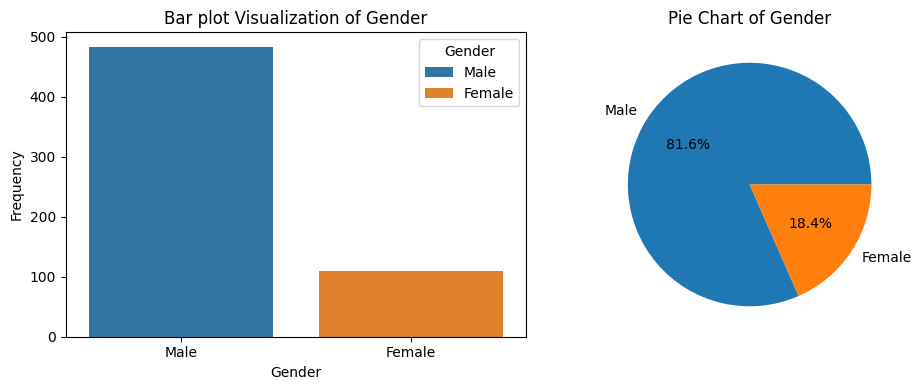

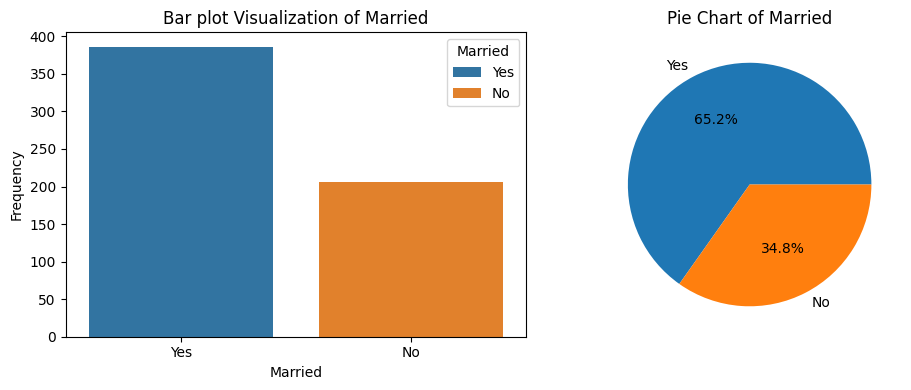

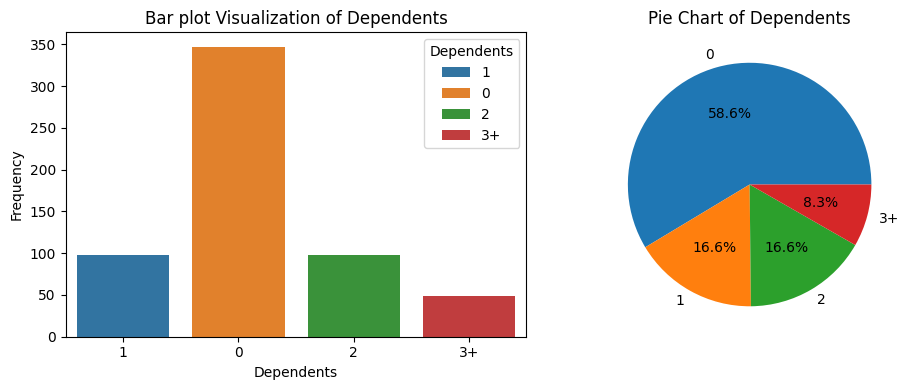

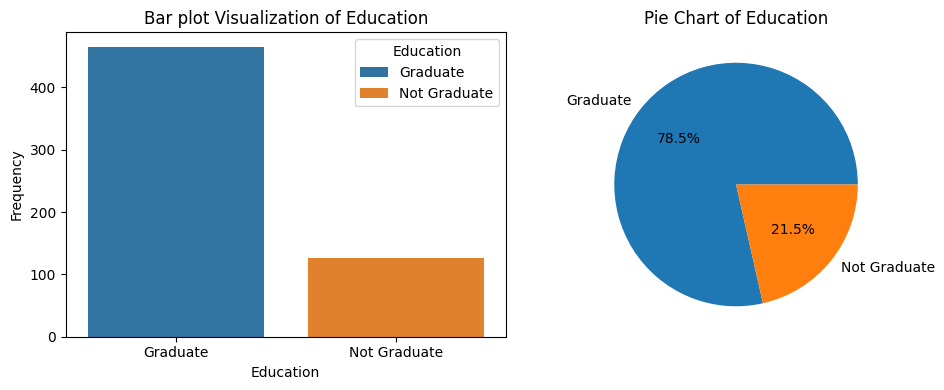

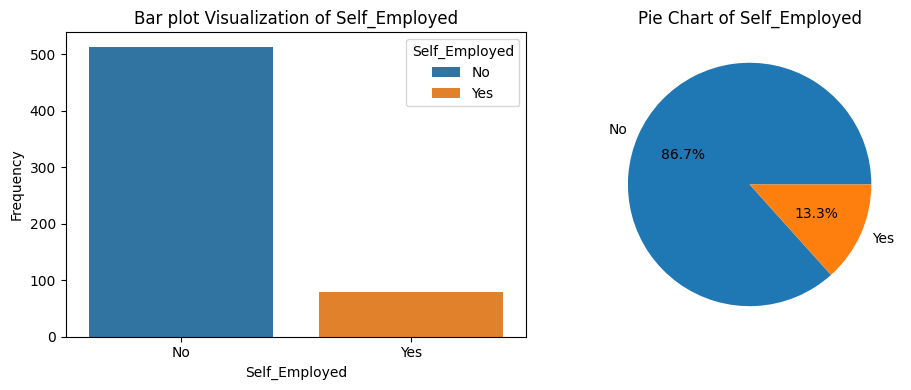

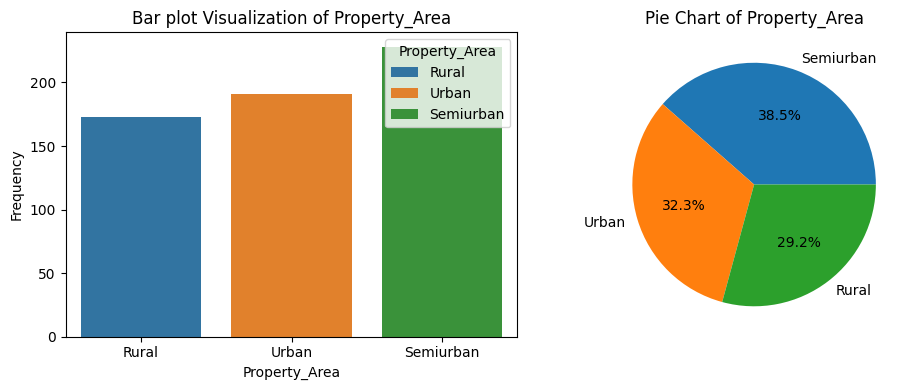

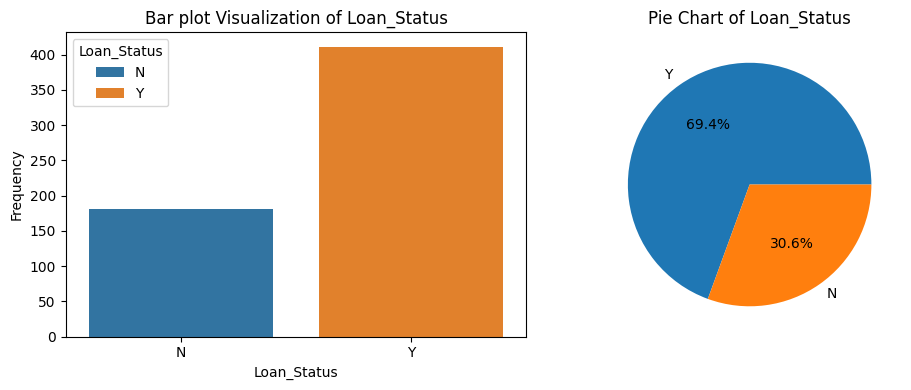

In [424]:
for feature in categorical_features:
    cat_feature_ana(df, feature)

BIVARIATE ANALYSIS

Task 2.4: Examine relationships between features and the target variable (loan approval status) 
using scatter plots, correlation matrices, and cross-tabulations.

In [425]:
df["Loan_Status"] = df["Loan_Status"].replace({"Y": 1, "N": 0})
df["Loan_Status"].head()

C:\Users\Osisami\AppData\Local\Temp\ipykernel_6592\1155243155.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Loan_Status"] = df["Loan_Status"].replace({"Y": 1, "N": 0})


Loan_ID
LP001003    0
LP001005    1
LP001006    1
LP001008    1
LP001011    1
Name: Loan_Status, dtype: int64

In [426]:
df["Loan_Status"].dtype

dtype('int64')

In [427]:
def correlation_with_target(df, target_col):
    """ 
    Plots a heatmap showing correlation of each numeric feature against target_col.
    Returns a Series of correlations (sorted by absolute magnitude). 
    """
    
    # Call only numeric columns and check if the target exists therein
    numerical_df = df.select_dtypes(include='number').copy()
    
    if target_col not in numerical_df.columns:
        raise ValueError(f"Target column '{target_col}' must be numerical and present in the dataframe.")
    
    # compute correlations of every numeric column with the target
    corrs = numerical_df.corrwith(numerical_df[target_col]).drop(target_col)
    
    corrs_df = corrs.to_frame(name='corr').T
    
    plt.figure(figsize=(10,2))
    sns.heatmap(
        corrs_df,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={"orientation": "vertical", "shrink":0.7}
    )
    plt.xticks(rotation=30, ha='right')
    plt.yticks([0], [target_col], rotation=0)
    plt.title(f"Correlation of numerical features with {target_col}", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # return sorted correlations for downstream use
    return corrs.reindex(corrs.abs().sort_values(ascending=False).index) 

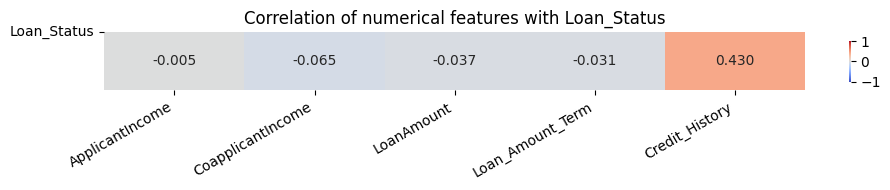

Credit_History       0.429578
CoapplicantIncome   -0.065034
LoanAmount          -0.037318
Loan_Amount_Term    -0.031256
ApplicantIncome     -0.004514
dtype: float64


In [428]:
corr_series = correlation_with_target(df, "Loan_Status")
print(corr_series)


In [429]:
from scipy.stats import pearsonr

def numeric_bivariate_plot(df, x_col, y_col):
    """ 
    Plots the relationship between two numeric variables with a regression line 
    and displays the correlation coefficient.
    
    Parameters:
    -----------
    data : pandas.DataFrame
         Dataset containing  the numeric columns
    x_col : str
        Name of the first numeric variable (x-axis)
    y_col : str
        Name of the second numeric variable (y-axis)
    """
    
    # Calculate correlation coefficient
    corr, p_value = pearsonr(df[x_col], df[y_col])
    
    # Create plot
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df, x=x_col, y=y_col, scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
    
    # Title and labels
    plt.title(f"{y_col} vs {x_col}\nCorrelation: {corr:.3f} (p={p_value:.3f})", fontsize=13)
    plt.xlabel(x_col, fontsize=11)
    plt.ylabel(y_col, fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()

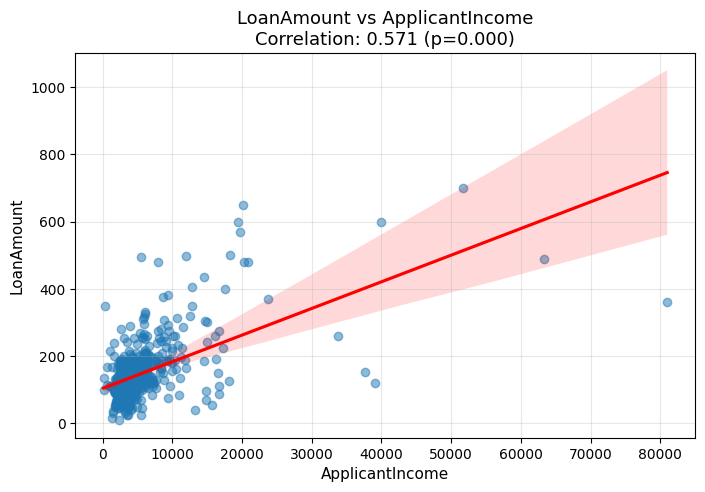

In [430]:
numeric_bivariate_plot(df, "ApplicantIncome", "LoanAmount")

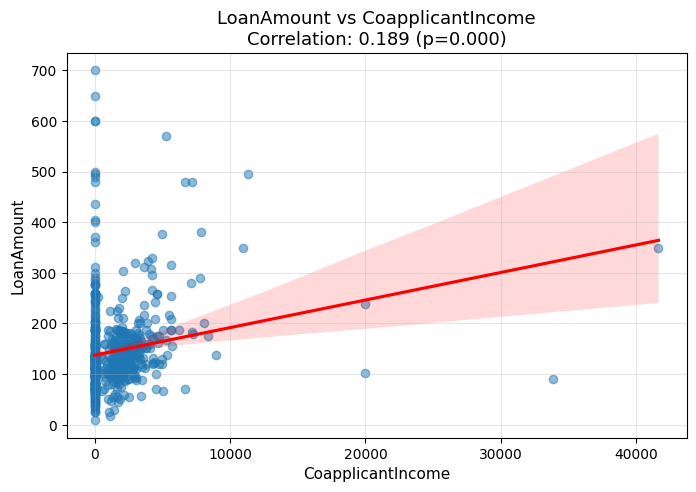

In [431]:
numeric_bivariate_plot(df, "CoapplicantIncome", "LoanAmount")

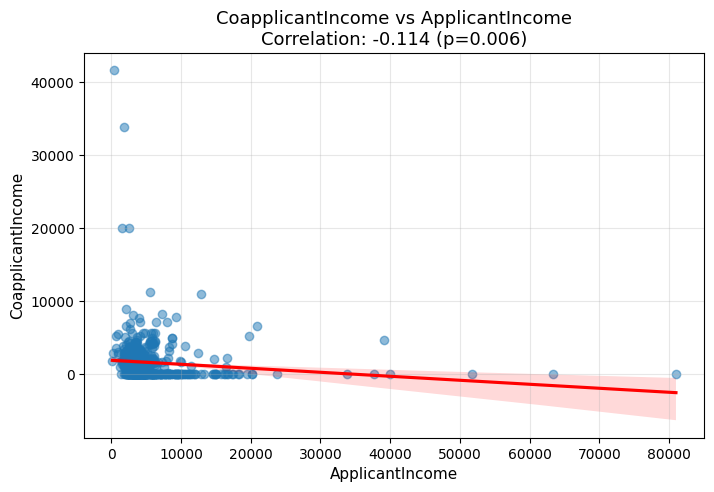

In [432]:

numeric_bivariate_plot(df, 'ApplicantIncome', 'CoapplicantIncome')

TRIVARIATE ANALYSIS

In [433]:
# To perform this, I need to define the function by comparing two features against the target variable

def trivariate_plot(df, x_col, y_col, hue_col):
    """
    Visualizes the relationship between two numeric variables (x_col, y_col)
    with a third target variable (loan approval status) shown by color (hue)
    
    Parameters
    ----------
    data : pandas.DataFrame
        The dataset.
    x_col : str
        The first numeric feature (x-axis).
    y_col : str
        The second numeric feature (y-axis).
    hue_col : str
        The target feature (color grouping).
    """
    
    plt.figure(figsize=(8, 6))
    sns.lmplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,
        height=6,
        aspect=1.2,
        scatter_kws={'alpha':0.6},
        line_kws={'linewidth':2}
    )
    plt.title(f"{y_col} vs {x_col} by {hue_col}", fontsize=13)
    plt.xlabel(x_col, fontsize=11)
    plt.ylabel(y_col, fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()

<Figure size 800x600 with 0 Axes>

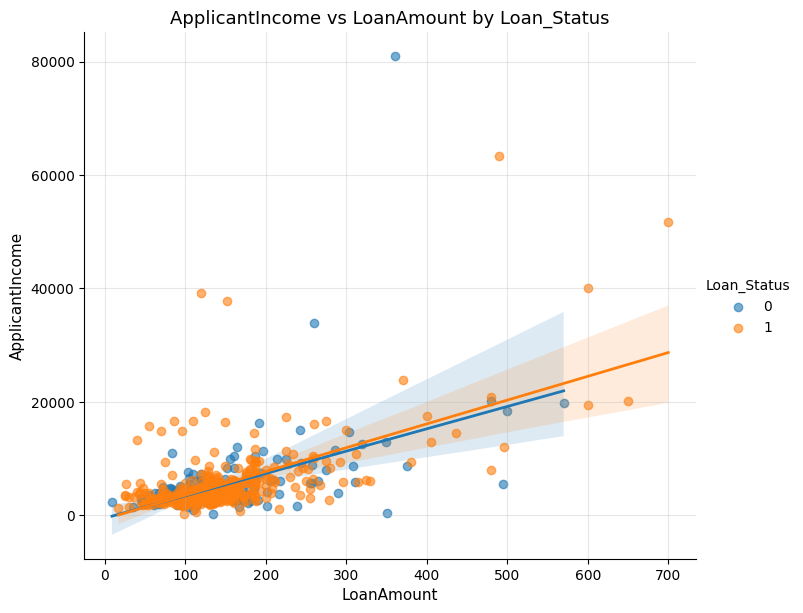

In [434]:
trivariate_plot(df, "LoanAmount", "ApplicantIncome", "Loan_Status")

# Building BASELINE MODEL

In [435]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [436]:
# Action Points:
# univariate
# 1- Skewed variables - log-transform
# 2- Outlier - IQR or winsorizing
# 3- 

In [437]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [438]:
from sklearn.preprocessing import LabelEncoder

data = df.copy()

# encode categorical columns
label_enc =LabelEncoder()
data = data.apply(lambda col:label_enc.fit_transform(col.astype(str)) if col.dtypes=="object" else col)

data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
LP001011,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1


In [439]:
# let's split our data
y = data["Loan_Status"]
X = data.drop(columns=["Loan_Status"])

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=234)

In [440]:
# lets use logistic regression algorithm to train our base model

model = LogisticRegression(solver='lbfgs', random_state=234, max_iter=10)
model.fit(X_train, y_train)

c:\Users\Osisami\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,234
,solver,'lbfgs'
,max_iter,10
,multi_class,'deprecated'


c:\Users\Osisami\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Osisami\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Osisami\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.70      1.00      0.82        83

    accuracy                           0.70       119
   macro avg       0.35      0.50      0.41       119
weighted avg       0.49      0.70      0.57       119



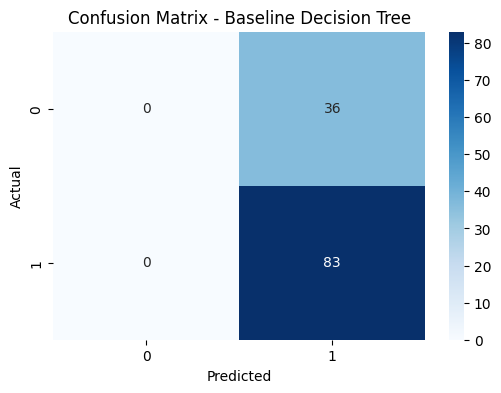

In [441]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion Matrix 
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Baseline Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [442]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
LP001011,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1


In [443]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [444]:
df.to_csv("EDA_homeloan_dataset.csv")